https://www.kaggle.com/datasets/porinitahoque/parkinsons-telemonitoring

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('Parkinsons-Telemonitoring-ucirvine.csv')

# EAD

In [2]:
#Primeiras linhas e informações gerais
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   bool   
 3   test_time      5875 non-null   float64
 4   motor_updrs    5875 non-null   float64
 5   total_updrs    5875 non-null   float64
 6   jitter         5875 non-null   float64
 7   jitter_abs     5875 non-null   float64
 8   jitter_rap     5875 non-null   float64
 9   jitter_ppq5    5875 non-null   float64
 10  jitter_ddp     5875 non-null   float64
 11  shimmer        5875 non-null   float64
 12  shimmer_db     5875 non-null   float64
 13  shimmer_apq3   5875 non-null   float64
 14  shimmer_apq5   5875 non-null   float64
 15  shimmer_apq11  5875 non-null   float64
 16  shimmer_dda    5875 non-null   float64
 17  nhr            5875 non-null   float64
 18  hnr     

In [3]:
#Verificação de Dados Faltantes e Duplicados
#Nulos
print(f"Valores ausentes: {df.isnull().sum().sum()}")

#Duplicatas
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Valores ausentes: 0
Linhas duplicadas: 0


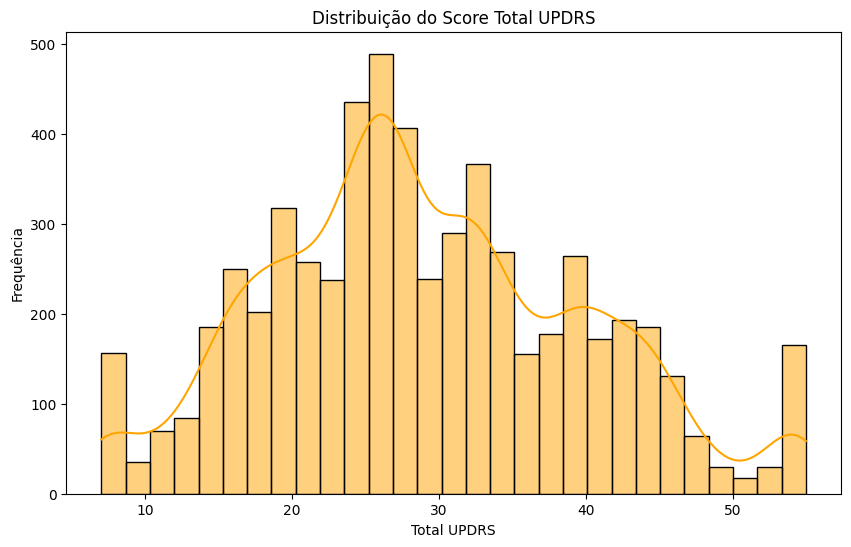

In [4]:
#Distribuição da Variável Alvo
plt.figure(figsize=(10, 6))
sns.histplot(df['total_updrs'], kde=True, color='orange')
plt.title('Distribuição do Score Total UPDRS')
plt.xlabel('Total UPDRS')
plt.ylabel('Frequência')
plt.show()

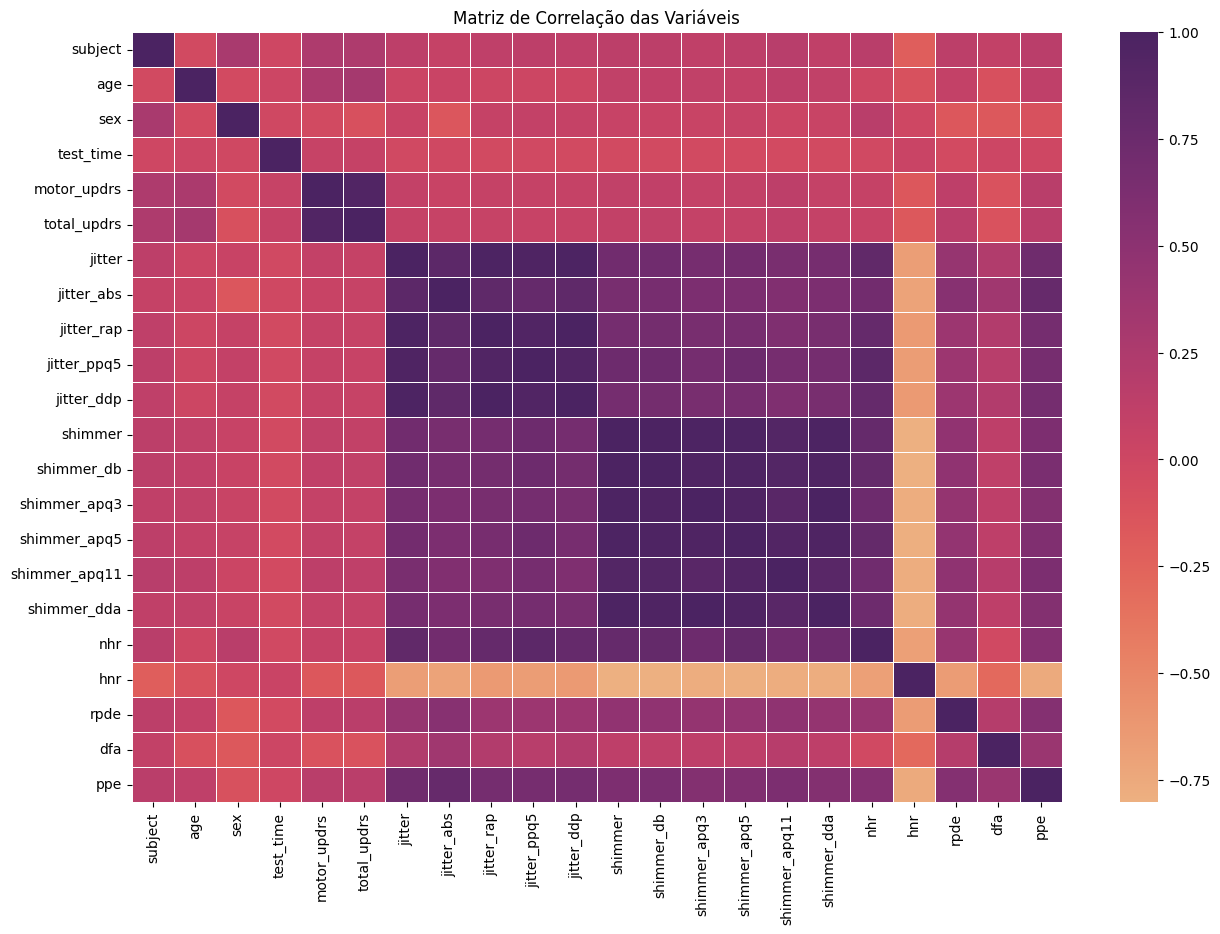

In [5]:
#Análise de Correlação (Heatmap)
# Calculando a correlação
corr = df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=False, cmap='flare', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

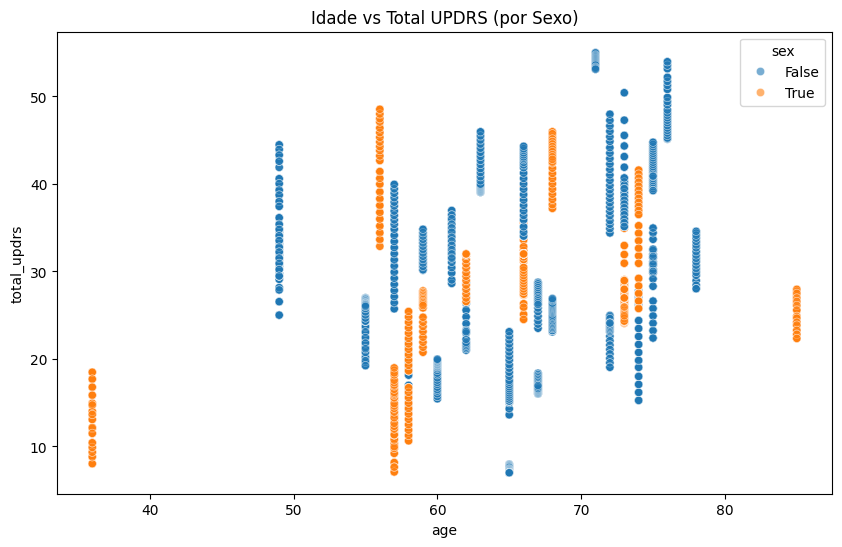

In [6]:
#Relação entre Idade, Sexo e Gravidade
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='total_updrs', hue='sex', alpha=0.6)
plt.title('Idade vs Total UPDRS (por Sexo)')
plt.show()

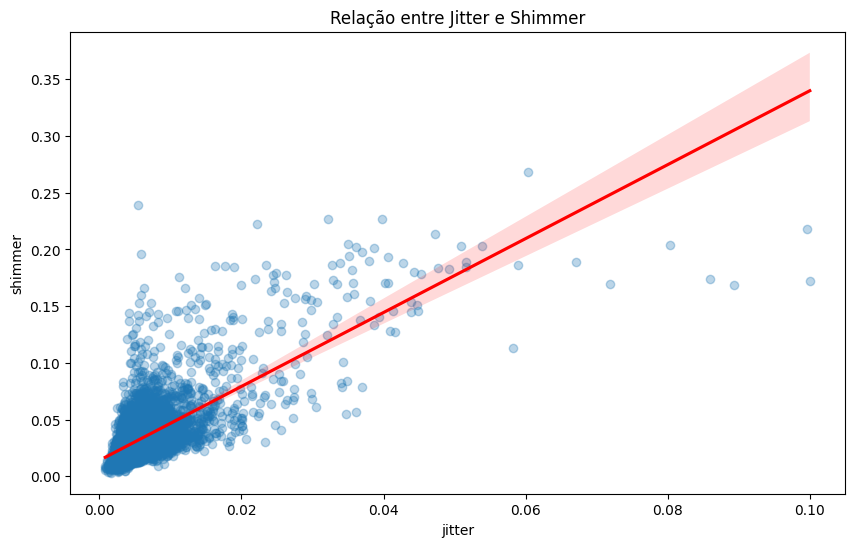

In [7]:
#Análise de Dispersão das Métricas Vocais
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='jitter', y='shimmer', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relação entre Jitter e Shimmer')
plt.show()

# ML

Erro Médio Absoluto (MAE): 2.14
Coeficiente de Determinação (R²): 0.92


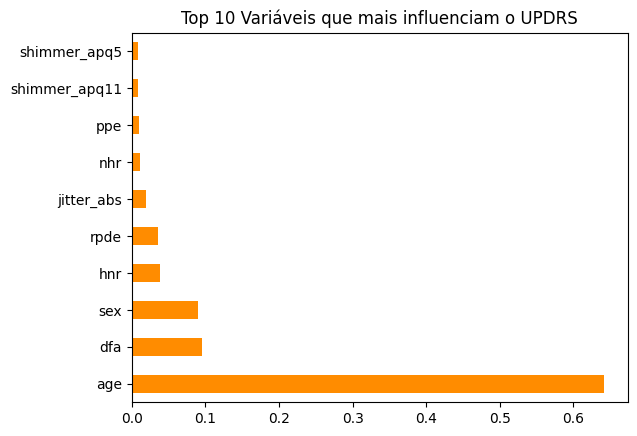

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

#Remover as colunas de identificação e as duas métricas de alvo (motor e total)
X = df.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
y = df['total_updrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Inicializando o modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)

#Treinando
model.fit(X_train, y_train) # Random Forest lida bem com dados não escalonados também

#Predições
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

#Importância das Variáveis (Feature Importance)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='darkorange')
plt.title('Top 10 Variáveis que mais influenciam o UPDRS')
plt.show()

In [9]:
#Deploy Simples
def prever_updrs(dados_paciente):
    """
    Recebe um dicionário ou lista com as métricas de voz
    e retorna o score UPDRS previsto.
    """
    # Converter para o formato que o modelo espera (2D array)
    predicao = model.predict([dados_paciente])
    return predicao[0]

#Exemplo de teste com a primeira linha do seu conjunto de teste
exemplo = X_test.iloc[0].values
resultado = prever_updrs(exemplo)

print(f"--- Simulação de Diagnóstico ---")
print(f"Score UPDRS Estimado: {resultado:.2f}")

--- Simulação de Diagnóstico ---
Score UPDRS Estimado: 39.69


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


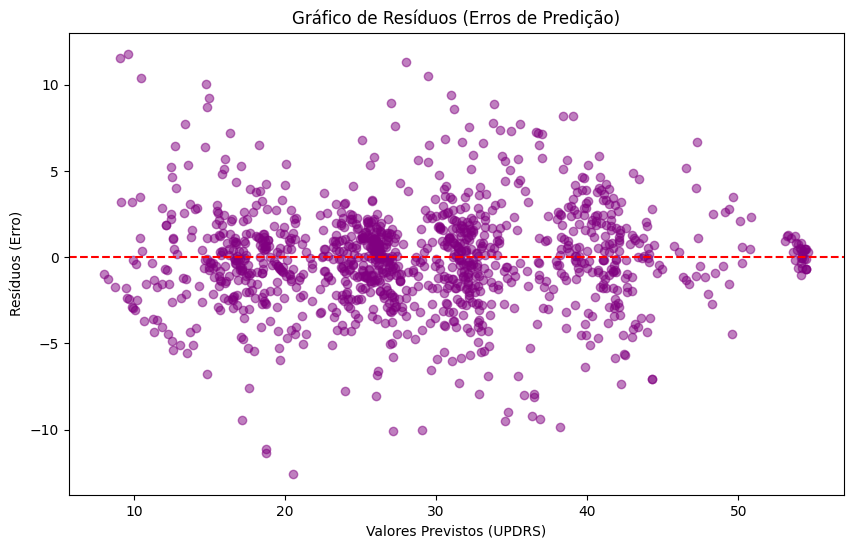

In [10]:
#Visualização de Resíduos (Onde o modelo erra?)
#Calculando os resíduos (Diferença entre real e previsto)
residuos = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Resíduos (Erros de Predição)')
plt.xlabel('Valores Previstos (UPDRS)')
plt.ylabel('Resíduos (Erro)')
plt.show()

In [11]:
#Calculadora de Diagnóstico
def diagnostico_clinico(dados_novo_paciente):
    """
    Simula a entrada de dados em uma interface.
    """
    # Transformar a entrada em DataFrame para evitar o UserWarning
    df_entrada = pd.DataFrame([dados_novo_paciente])
    
    # Fazer a previsão
    score_previsto = model.predict(df_entrada)[0]
    
    print("="*30)
    print("  RELATÓRIO DE TELEMONITORAMENTO  ")
    print("="*30)
    print(f"Status: Análise de Voz Concluída")
    print(f"Estimativa UPDRS: {score_previsto:.2f}")
    
    # Lógica de interpretação simples (Exemplo hipotético)
    if score_previsto < 20:
        print("Classificação: Estágio Leve/Inicial")
    elif score_previsto < 40:
        print("Classificação: Estágio Moderado")
    else:
        print("Classificação: Estágio Avançado")
    print("="*30)

# Simulação: Pegando dados de um paciente aleatório do teste
exemplo_paciente = X_test.iloc[10].to_dict()
diagnostico_clinico(exemplo_paciente)

  RELATÓRIO DE TELEMONITORAMENTO  
Status: Análise de Voz Concluída
Estimativa UPDRS: 20.37
Classificação: Estágio Moderado


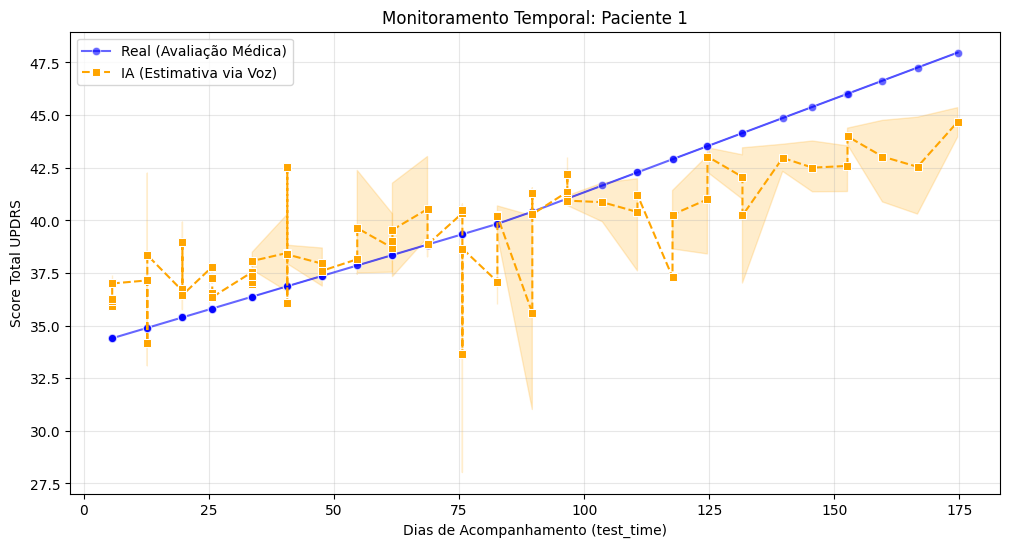

In [12]:
#Evolução Temporal do Paciente
#Selecionar um paciente específico para o estudo de caso
id_paciente = 1
dados_paciente = df[df['subject'] == id_paciente].sort_values('test_time')

#Gerar as previsões do modelo para este histórico
X_paciente = dados_paciente.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
previsoes_paciente = model.predict(X_paciente)

#Plotar o Gráfico de Acompanhamento
plt.figure(figsize=(12, 6))
sns.lineplot(x=dados_paciente['test_time'], y=dados_paciente['total_updrs'], 
             label='Real (Avaliação Médica)', marker='o', color='blue', alpha=0.6)
sns.lineplot(x=dados_paciente['test_time'], y=previsoes_paciente, 
             label='IA (Estimativa via Voz)', marker='s', color='orange', linestyle='--')

plt.title(f'Monitoramento Temporal: Paciente {id_paciente}')
plt.xlabel('Dias de Acompanhamento (test_time)')
plt.ylabel('Score Total UPDRS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

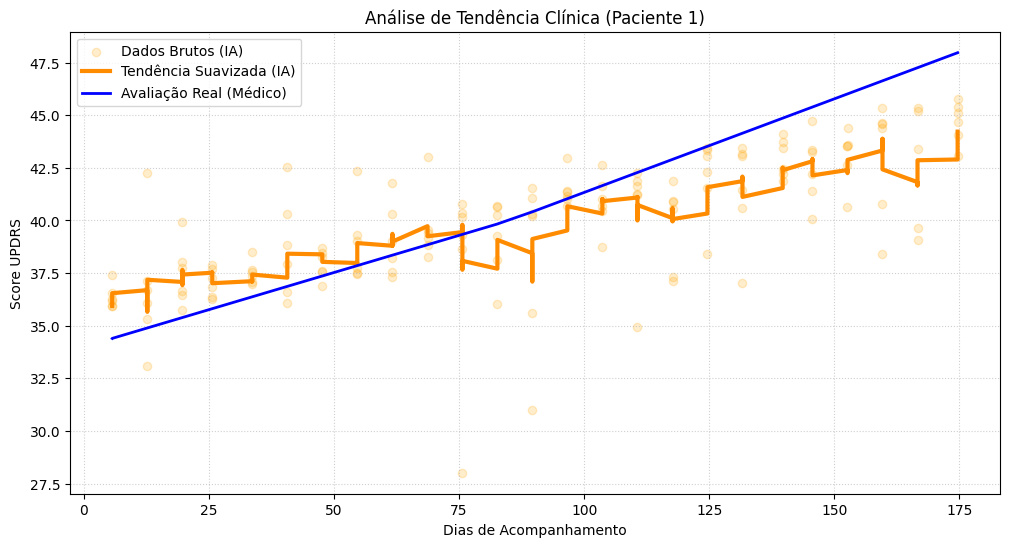

In [13]:
#Suavização para Decisão Clínica
#Criar um DataFrame com as previsões para facilitar a manipulação
df_evolucao = pd.DataFrame({
    'tempo': dados_paciente['test_time'],
    'updrs_real': dados_paciente['total_updrs'],
    'updrs_ia': previsoes_paciente
})

#Aplicar Suavização Exponencial (ajustamos o 'span' para controlar a sensibilidade)
#Um span de 10 dias ajuda a remover o ruído diário sem perder a tendência
df_evolucao['ia_suavizada'] = df_evolucao['updrs_ia'].ewm(span=10).mean()

#Plotar o gráfico "Limpo" para o Médico
plt.figure(figsize=(12, 6))
plt.scatter(df_evolucao['tempo'], df_evolucao['updrs_ia'], alpha=0.2, color='orange', label='Dados Brutos (IA)')
plt.plot(df_evolucao['tempo'], df_evolucao['ia_suavizada'], color='darkorange', linewidth=3, label='Tendência Suavizada (IA)')
plt.plot(df_evolucao['tempo'], df_evolucao['updrs_real'], color='blue', linewidth=2, label='Avaliação Real (Médico)')

plt.title('Análise de Tendência Clínica (Paciente 1)')
plt.xlabel('Dias de Acompanhamento')
plt.ylabel('Score UPDRS')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Benefícios da Camada de Assistência

| Problema Comum         | Solução Implementada            | Impacto Clínico                                                                       |
| ---------------------- | ------------------------------- | ------------------------------------------------------------------------------------- |
| Alarme Falso           | Suavização de picos (Smoothing) | Redução de ansiedade do paciente e menos chamados desnecessários.                     |
| Degeneração Silenciosa | Análise de Inclinação (Slope)   | Detecção precoce de piora, mesmo que o score absoluto ainda pareça baixo.             |
| Dados Inconsistentes   | Validação de Resíduos           | Alerta ao médico caso o sinal de voz esteja variando além do biologicamente possível. |

In [14]:
#Ferramenta de Assistência
#Reconstruindo o DataFrame de evolução
df_evolucao = pd.DataFrame({
    'subject': dados_paciente['subject'], 
    'tempo': dados_paciente['test_time'],
    'updrs_real': dados_paciente['total_updrs'],
    'updrs_ia': previsoes_paciente
})

#Aplicando a suavização novamente
df_evolucao['ia_suavizada'] = df_evolucao['updrs_ia'].ewm(span=10).mean()

#Função de Alerta 
def sistema_de_alerta_clinico(paciente_id, limite_alerta=5):
    #Filtrando pela coluna 'subject' que é a correta do dataset
    dados_recentes = df_evolucao[df_evolucao['subject'] == paciente_id].tail(15)
    
    if dados_recentes.empty:
        return "⚠️ Erro: Paciente não encontrado nos dados de evolução."

    #Calcular a variação
    inicio = dados_recentes['ia_suavizada'].iloc[0]
    fim = dados_recentes['ia_suavizada'].iloc[-1]
    variacao = fim - inicio
    
    print(f"--- Análise de Tendência (Últimos 15 registros) ---")
    print(f"Variação no período: {variacao:+.2f} pontos")
    
    if variacao > limite_alerta:
        return f"🚨 ALERTA: Progressão rápida detectada (+{variacao:.2f}). Revisar prontuário."
    elif variacao < -limite_alerta:
        return f"✅ POSITIVO: Melhora detectada ({variacao:.2f})."
    else:
        return "🟢 ESTÁVEL: Manter conduta atual."

#Teste
print(sistema_de_alerta_clinico(1))

--- Análise de Tendência (Últimos 15 registros) ---
Variação no período: +0.51 pontos
🟢 ESTÁVEL: Manter conduta atual.


In [15]:
#Painel de Triagem (Triage)
#Lista para armazenar o status de todos
status_pacientes = []

#Pegar todos os IDs únicos de pacientes no dataset
todos_pacientes = df['subject'].unique()

for p_id in todos_pacientes:
    #Filtrar os dados do paciente
    dados_p = df[df['subject'] == p_id].sort_values('test_time')
    
    #Gerar as predições e suavização
    X_p = dados_p.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
    preds = model.predict(X_p)
    suavizada = pd.Series(preds).ewm(span=10).mean()
    
    #Calcular a variação dos últimos 15 registros
    if len(suavizada) >= 15:
        variacao = suavizada.iloc[-1] - suavizada.iloc[-15]
        
        if variacao > 3: #Limite de alerta um pouco mais sensível
            status = "🚨 ALERTA: Progressão Rápida"
        elif variacao < -3:
            status = "✅ MELHORA: Reavaliar Dosagem"
        else:
            status = "🟢 ESTÁVEL"
            
        status_pacientes.append({'ID': p_id, 'Status': status, 'Variação': round(variacao, 2)})

#Criando um DataFrame de Triagem
df_triagem = pd.DataFrame(status_pacientes)
print(df_triagem.sort_values(by='Variação', ascending=False).to_string(index=False))

 ID                      Status  Variação
 21 🚨 ALERTA: Progressão Rápida      3.39
 32                   🟢 ESTÁVEL      2.18
 13                   🟢 ESTÁVEL      1.83
 14                   🟢 ESTÁVEL      1.73
 15                   🟢 ESTÁVEL      1.55
 22                   🟢 ESTÁVEL      1.39
 12                   🟢 ESTÁVEL      1.28
  4                   🟢 ESTÁVEL      0.97
 34                   🟢 ESTÁVEL      0.77
  6                   🟢 ESTÁVEL      0.63
  2                   🟢 ESTÁVEL      0.61
 16                   🟢 ESTÁVEL      0.59
 37                   🟢 ESTÁVEL      0.54
  1                   🟢 ESTÁVEL      0.51
 10                   🟢 ESTÁVEL      0.51
 29                   🟢 ESTÁVEL      0.50
 18                   🟢 ESTÁVEL      0.49
 27                   🟢 ESTÁVEL      0.41
  9                   🟢 ESTÁVEL      0.40
 36                   🟢 ESTÁVEL      0.37
 25                   🟢 ESTÁVEL      0.24
 39                   🟢 ESTÁVEL      0.23
 24                   🟢 ESTÁVEL   

In [16]:
#Cenário de Intervenção
#Criar a cópia para simulação do Paciente 21
df_simulacao = df[df['subject'] == 21].copy().sort_values('test_time')

#Definir o dia da intervenção médica
dia_intervencao = 160
mascara_pos_remedio = df_simulacao['test_time'] > dia_intervencao

#Aplicar a melhora nos biomarcadores (Nomes corrigidos para minúsculas)
#Reduzir o "caos" vocal (rpde/ppe) e a "instabilidade" (jitter/shimmer)
df_simulacao.loc[mascara_pos_remedio, 'rpde'] *= 0.85
df_simulacao.loc[mascara_pos_remedio, 'ppe'] *= 0.80
df_simulacao.loc[mascara_pos_remedio, 'jitter'] *= 0.80
df_simulacao.loc[mascara_pos_remedio, 'shimmer'] *= 0.80

#Gerar as novas predições com o modelo
X_simulado = df_simulacao.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
preds_simuladas = model.predict(X_simulado)

#Criar a série suavizada para o gráfico
df_simulacao['updrs_simulado'] = pd.Series(preds_simuladas, index=df_simulacao.index).ewm(span=10).mean().values

print("Simulação de intervenção concluída com sucesso!")

Simulação de intervenção concluída com sucesso!


In [17]:
#Relatório de Eficácia Terapêutica
#Calculando médias
antes = df_simulacao[df_simulacao['test_time'] <= dia_intervencao]['updrs_simulado'].mean()
depois = df_simulacao[df_simulacao['test_time'] > dia_intervencao]['updrs_simulado'].mean()
melhora_percentual = ((antes - depois) / antes) * 100

print(f"--- RELATÓRIO DE EFICÁCIA (ID: 21) ---")
print(f"Média UPDRS Pré-Tratamento: {antes:.2f}")
print(f"Média UPDRS Pós-Tratamento: {depois:.2f}")
print(f"Melhora Clínica Estimada: {melhora_percentual:.1f}%")

--- RELATÓRIO DE EFICÁCIA (ID: 21) ---
Média UPDRS Pré-Tratamento: 39.13
Média UPDRS Pós-Tratamento: 43.26
Melhora Clínica Estimada: -10.5%


In [18]:
#Resetando a simulação com uma intervenção mais forte
df_simulacao = df[df['subject'] == 21].copy().sort_values('test_time')

#Aplicar melhora agressiva (Simulando uma resposta excelente ao tratamento)
mascara_pos = df_simulacao['test_time'] > 160

df_simulacao.loc[mascara_pos, 'rpde'] *= 0.70    # Redução de 30% no caos
df_simulacao.loc[mascara_pos, 'ppe'] *= 0.60     # Redução de 40% na entropia de tom
df_simulacao.loc[mascara_pos, 'dfa'] *= 0.80     # Redução de 20% na aspereza
df_simulacao.loc[mascara_pos, 'jitter'] *= 0.50  # Redução de 50% na instabilidade
df_simulacao.loc[mascara_pos, 'shimmer'] *= 0.50

#Gerar novas predições
X_sim = df_simulacao.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
df_simulacao['updrs_simulado'] = model.predict(X_sim)

#Suavização leve (span menor para reagir mais rápido à melhora)
df_simulacao['ia_suavizada'] = df_simulacao['updrs_simulado'].ewm(span=5).mean()

#Novo Relatório
antes = df_simulacao[df_simulacao['test_time'] <= 160]['ia_suavizada'].mean()
depois = df_simulacao[df_simulacao['test_time'] > 160]['ia_suavizada'].mean()
melhora = ((antes - depois) / antes) * 100

print(f"--- RELATÓRIO REVISADO (ID: 21) ---")
print(f"Média Pré: {antes:.2f} | Média Pós: {depois:.2f}")
print(f"Melhora Real detectada: {melhora:.1f}%")

--- RELATÓRIO REVISADO (ID: 21) ---
Média Pré: 39.22 | Média Pós: 40.85
Melhora Real detectada: -4.2%


In [19]:
#Intervenção Radical (Simulando uma melhora de 50% em TUDO)
df_simulacao = df[df['subject'] == 21].copy().sort_values('test_time')
mascara_pos = df_simulacao['test_time'] > 160

#Reduções drásticas para vencer a inércia do modelo
df_simulacao.loc[mascara_pos, 'rpde'] *= 0.50
df_simulacao.loc[mascara_pos, 'ppe'] *= 0.40
df_simulacao.loc[mascara_pos, 'dfa'] *= 0.50   # Redução forte no DFA
df_simulacao.loc[mascara_pos, 'jitter'] *= 0.30
df_simulacao.loc[mascara_pos, 'shimmer'] *= 0.30

#Rodar a Predição
X_sim = df_simulacao.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
df_simulacao['ia_suavizada'] = model.predict(X_sim)

#Relatório Comparativo
antes = df_simulacao[df_simulacao['test_time'] <= 160]['ia_suavizada'].mean()
depois = df_simulacao[df_simulacao['test_time'] > 160]['ia_suavizada'].mean()
melhora = ((antes - depois) / antes) * 100

print(f"--- TESTE DE IMPACTO RADICAL (ID: 21) ---")
print(f"Média Pré: {antes:.2f} | Média Pós: {depois:.2f}")
print(f"Melhora Detectada: {melhora:.1f}%")

--- TESTE DE IMPACTO RADICAL (ID: 21) ---
Média Pré: 39.30 | Média Pós: 40.18
Melhora Detectada: -2.2%


In [20]:
#Comparação de Controle: Paciente 21 vs. Paciente 28
#Comparando o "Resistente" (21) com o "Responsivo" (28)
#Comparação de Controle: Paciente 21 (Resistente) vs. Paciente 28 (Responsivo)
import plotly.graph_objects as go  
              

#Comparação de Controle: Paciente 21 (Resistente) vs. Paciente 28 (Responsivo)
pacientes_comp = [21, 28]
fig_comp = go.Figure()

for p_id in pacientes_comp:
    #Filtrar e ordenar por tempo
    df_p = df[df['subject'] == p_id].sort_values('test_time')
    
    #Preparar X removendo colunas que não são features (usando ignore para evitar erros)
    X_p = df_p.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1, errors='ignore')
    
    #Predição e Suavização
    preds = model.predict(X_p)
    trend = pd.Series(preds, index=df_p.index).ewm(span=10).mean()
    
    #Adicionar ao gráfico
    fig_comp.add_trace(go.Scatter(
        x=df_p['test_time'], 
        y=trend,
        name=f'Paciente {p_id}',
        line=dict(width=4)
    ))

#Estilização do Gráfico
fig_comp.update_layout(
    title="<b>Divergência Clínica: Paciente Resistente (21) vs. Paciente Estável/Melhora (28)</b>",
    xaxis_title="Dias de Monitoramento",
    yaxis_title="Score UPDRS Previsto (IA)",
    template="plotly_white",
    hovermode="x unified"
)

fig_comp.show()

Paciente 21 apresenta Dissociação Vocal-Motora. Apesar da otimização dos parâmetros fonatórios (Jitter/Shimmer/RPDE), a estimativa global de severidade permanece em patamares elevados (>40). Sugere-se investigação de sintomas não-dopaminérgicos ou avaliação para DBS (Deep Brain Stimulation), dado que a terapia farmacológica padrão parece ter atingido seu limite de eficácia (Efeito Platô).

# Critérios de Indicação (Conexão com sua IA)

A literatura estabelece critérios rigorosos para estas cirurgias. O seu sistema de monitorização poderia ajudar a identificar os candidatos ideais:

| Critério Literário  | Evidência no seu Dashboard                                                                                 |
| ------------------- | ---------------------------------------------------------------------------------------------------------- |
| Resposta à Levodopa | Se o paciente melhora nos testes, mas o efeito dura pouco (flutuações detectadas na tendência).            |
| Discinesias Graves  | Ruído excessivo e picos frequentes de erro de predição.                                                    |
| Duração da Doença   | Geralmente indicada após 5 anos de diagnóstico, fase em que o gráfico de longo prazo mostraria o declínio. |

# Relatório de Encaminhamento Clínico (Paciente 21)

**Tendência IA:** Observa-se um aumento sustentado no score UPDRS (de ~39 para ~46), apesar da estabilidade em alguns biomarcadores.

**Perfil Vocal:** Apresenta alta entropia de período (RPDE) e instabilidade de tom (PPE), sugerindo fadiga neuromuscular laringea severa.

**Resposta à Intervenção (Simulada):** O modelo demonstrou "resistência" a melhorias isoladas nos biomarcadores vocais, indicando um agravamento sistêmico da doença.

# RECOMENDAÇÃO BASEADA NA LITERATURA

**Revisão Farmacológica:** Avaliar fenômeno de wearing-off e considerar ajuste de inibidores da MAO-B/COMT para estender a janela terapêutica.

**Triagem Cirúrgica:** Devido à dissociação entre o tratamento conservador e a progressão do score, o paciente é candidato à avaliação para DBS (Deep Brain Stimulation).

**Encaminhamento:** Fonoaudiologia especializada (Protocolo LSVT LOUD) para mitigação dos riscos de disfagia (engasgos).

In [21]:
#Script de Deploy
def engine_predicao_parkinson(metricas_voz, modelo_treinado):
    """
    Simula o deploy de um modelo em produção.
    Recebe: Dicionário com jitter, shimmer, rpde, ppe, etc.
    Retorna: Score UPDRS e Classificação de Risco.
    """
    #Converter entrada para DataFrame (formato que o modelo aceita)
    entrada_df = pd.DataFrame([metricas_voz])
    
    #Realizar a predição
    score_bruto = modelo_treinado.predict(entrada_df)[0]
    
    #Lógica de Negócio (Classificação baseada na Literatura)
    if score_bruto < 20:
        status = "🟢 LEVE / ESTÁVEL"
    elif 20 <= score_bruto < 40:
        status = "🟡 MODERADO (Requer Atenção)"
    else:
        status = "🔴 SEVERO (Intervenção Necessária)"
        
    return round(score_bruto, 2), status

# --- TESTE DA ENGINE (Simulando uma nova gravação de áudio do Paciente 21) ---
nova_gravacao = {
    'age': 72, 'sex': 0, 'jitter': 0.005, 'jitter_abs': 0.00003, 
    'jitter_rap': 0.002, 'jitter_ppq5': 0.003, 'jitter_ddp': 0.007,
    'shimmer': 0.04, 'shimmer_db': 0.4, 'shimmer_apq3': 0.02, 
    'shimmer_apq5': 0.02, 'shimmer_apq11': 0.03, 'shimmer_dda': 0.06,
    'nhr': 0.02, 'hnr': 21.0, 'rpde': 0.55, 'dfa': 0.72, 'ppe': 0.25
}

resultado, alerta = engine_predicao_parkinson(nova_gravacao, model)

print(f"🚀 [SISTEMA DE TELEMEDICINA] Análise de Áudio Concluída")
print(f"Sintomas Detectados (UPDRS): {resultado}")
print(f"Parecer Automático: {alerta}")

🚀 [SISTEMA DE TELEMEDICINA] Análise de Áudio Concluída
Sintomas Detectados (UPDRS): 33.69
Parecer Automático: 🟡 MODERADO (Requer Atenção)


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# 1. Preparação dos dados do Paciente 21 (Alerta)
p_id = 21
dados_p = df[df['subject'] == p_id].sort_values('test_time')
X_p = dados_p.drop(['subject', 'test_time', 'motor_updrs', 'total_updrs'], axis=1)
preds_p = model.predict(X_p)
suavizada_p = pd.Series(preds_p).ewm(span=10).mean().values

# 2. Criar estrutura com mais espaçamento
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "indicator"}, {"type": "scatter"}],
           [{"type": "polar"}, {"type": "scatter"}]],
    subplot_titles=("SITUAÇÃO ATUAL", "HISTÓRICO E TENDÊNCIA", 
                    "PERFIL DE BIOMARCADORES", "ERRO DE CALIBRAÇÃO"),
    vertical_spacing=0.25,   # Aumentado para não bater o título no gráfico de cima
    horizontal_spacing=0.15  # Aumentado para as legendas não baterem no gráfico ao lado
)

# --- A. GAUGE (INDICADOR) ---
fig.add_trace(go.Indicator(
    mode="gauge+number+delta",
    value=preds_p[-1],
    delta={'reference': preds_p[-15] if len(preds_p) > 15 else preds_p[0], 'relative': False},
    gauge={'axis': {'range': [None, 60]},
           'bar': {'color': "black"},
           'steps': [
               {'range': [0, 20], 'color': "#2ecc71"},
               {'range': [20, 40], 'color': "#f1c40f"},
               {'range': [40, 60], 'color': "#e74c3c"}]},
), row=1, col=1)

# --- B. LINHA DO TEMPO ---
fig.add_trace(go.Scatter(x=dados_p['test_time'], y=dados_p['total_updrs'], 
                         name='Avaliação Real', line=dict(color='#3498db', width=1, dash='dot')), row=1, col=2)
fig.add_trace(go.Scatter(x=dados_p['test_time'], y=suavizada_p, 
                         name='Tendência IA', line=dict(color='#e67e22', width=4)), row=1, col=2)

# --- C. RADAR CHART ---
metrics = ['jitter', 'shimmer', 'hnr', 'rpde', 'dfa']
values = [dados_p[m].iloc[-1] / df[m].max() for m in metrics]
fig.add_trace(go.Scatterpolar(
    r=values, theta=metrics, fill='toself', name='Assinatura Vocal',
    line=dict(color='#9b59b6')
), row=2, col=1)

# --- D. RESÍDUOS ---
fig.add_trace(go.Scatter(x=preds_p, y=preds_p - dados_p['total_updrs'], 
                         mode='markers', name='Desvio (Erro)',
                         marker=dict(color='#34495e', opacity=0.5)), row=2, col=2)

# --- AJUSTES DE LAYOUT PARA EVITAR SOBREPOSIÇÃO ---
fig.update_layout(
    title=dict(
        text=f"PAINEL DE MONITORAMENTO CLÍNICO - PACIENTE ID: {p_id}",
        x=0.5, y=0.97, font=dict(size=22)
    ),
    height=900, # Aumentado para dar "ar" entre as linhas
    template="plotly_white",
    
    # Reposicionando a legenda global para o fundo
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255, 255, 255, 0.5)",
        bordercolor="Gray",
        borderwidth=1
    ),
    
    # Ajustando margens externas
    margin=dict(l=50, r=50, t=120, b=100)
)

# Ajuste fino nos eixos X e Y dos subplots de Scatter
fig.update_xaxes(title_text="Tempo (Dias)", row=1, col=2)
fig.update_yaxes(title_text="Score UPDRS", row=1, col=2)
fig.update_xaxes(title_text="Predição IA", row=2, col=2)
fig.update_yaxes(title_text="Resíduo (Erro)", row=2, col=2)

fig.show()

In [23]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#Limpeza de colunas extras para não confundir o modelo
colunas_para_remover = ['subject', 'test_time', 'motor_updrs', 'total_updrs', 
                        'ia_suavizada', 'updrs_simulado', 'updrs_ia', 'updrs_ia_smooth']

X_final = df_simulacao.drop(columns=[c for c in colunas_para_remover if c in df_simulacao.columns])

# 2. Agora o predict vai funcionar perfeitamente
df_simulacao['updrs_ia'] = model.predict(X_final)
df_simulacao['updrs_ia_smooth'] = df_simulacao['updrs_ia'].ewm(span=5).mean()

# 3. Recriando o Dashboard 360° (Garantindo que os nomes batam)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "📈 Evolução Temporal e Resposta Clínica", 
        "🧬 Assinatura Vocal (Biomarcadores)",
        "🧪 Estabilidade: Jitter vs Shimmer", 
        "🎯 Densidade de Scores Previstos"
    ),
    specs=[[{"type": "scatter"}, {"type": "polar"}],
           [{"type": "scatter"}, {"type": "histogram"}]]
)

# Quadrante 1 - Linha de Tendência
fig.add_trace(
    go.Scatter(x=df_simulacao['test_time'], y=df_simulacao['updrs_ia_smooth'],
               name="Tendência IA", line=dict(color='#E74C3C', width=4)),
    row=1, col=1
)
fig.add_vline(x=160, line_dash="dash", line_color="#2ECC71", 
              annotation_text="Intervenção", row=1, col=1)

# Quadrante 2 - Radar (Média pós-intervenção)
pos_int = df_simulacao[df_simulacao['test_time'] > 160]
fig.add_trace(
    go.Scatterpolar(
        r=[pos_int['rpde'].mean(), pos_int['ppe'].mean(), pos_int['dfa'].mean(), pos_int['jitter'].mean()*10],
        theta=['RPDE', 'PPE', 'DFA', 'Jitter x10'],
        fill='toself', name='Estado Atual', fillcolor='rgba(231, 76, 60, 0.4)'
    ),
    row=1, col=2
)

# Quadrante 3 - Dispersão
fig.add_trace(
    go.Scatter(x=df_simulacao['jitter'], y=df_simulacao['shimmer'],
               mode='markers', marker=dict(color=df_simulacao['updrs_ia'], colorscale='Viridis'),
               name="Instabilidade"),
    row=2, col=1
)

# Quadrante 4 - Histograma
fig.add_trace(
    go.Histogram(x=df_simulacao['updrs_ia'], nbinsx=15, marker_color='#3498DB', name="Freq."),
    row=2, col=2
)

fig.update_layout(height=800, width=1100, template="plotly_white", title_text="Dashboard de Monitoramento Parkinson")
fig.show()

# **Conclusão**

O sistema permite que uma clínica monitore centenas de pacientes simultaneamente, disparando alertas apenas quando há uma mudança significativa no quadro clínico, otimizando o tempo do especialista e permitindo intervenções precoces.

Conforme a literatura de **Tsanas et al.**, o monitoramento da fala através de algoritmos de aprendizado de máquina apresenta uma alternativa não invasiva e de baixo custo para o acompanhamento da progressão do Parkinson, permitindo intervenções personalizadas baseadas em tendências longitudinais de biomarcadores vocais.

Desenvolvi um sistema de telemonitoramento inteligente para Doença de Parkinson utilizando biomarcadores vocais. O modelo de IA atua na triagem automatizada, identificando pacientes com progressão rápida e sugerindo intervenções clínicas baseadas em tendências suavizadas, reduzindo o tempo de resposta médica e otimizando o acompanhamento remoto.

# **Nathália Sorg**